# 🌊 HyFlood: Flood Map Reconstruction with Gaussian Processes

In the previous notebook, we simulated a set of representative compound
flooding scenarios with SFINCS and compressed the resulting flood maps with
**PCA**.

In this notebook, we build the **HyFlood surrogate model**: a statistical model
that relates the forcing conditions (waves, sea level and rain) to the flood
maps. Once trained, it can reconstruct a flood map for **any new scenario**
in a fraction of a second, without running SFINCS again.

**forcing conditions → GPR → PCs → inverse PCA → flood map**

We will use it to:

1. Reconstruct flood maps for new scenarios sampled with **LHS**.
2. Evaluate how the flooding caused by a reference storm changes under
   **sea level rise (SLR)**.

> **Inputs** (generated in `01_Propagation.ipynb`):
> - PCA model of the SFINCS flood maps: `export/pca_model.pkl`
> - Forcing conditions of the simulated scenarios: `export/mda_centroids.pkl`
> - Full LHS dataset: `export/lhs_dataset.pkl`

In [1]:
import logging
import os
import os.path as op

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from bluemath_tk.core.io import load_model

from utils.gps import ExactGPInterpolation
from utils.plotting import plot_output_cases
from utils.reconstruction import flooded_area_km2, pcs_to_flood_maps, sample_pcs

# Keep the notebook output clean
logging.getLogger("ExactGPInterpolation").setLevel(logging.WARNING)
logging.getLogger("PCA").setLevel(logging.WARNING)

In [2]:
root_dir = os.getcwd()

templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")

dep_hr = xr.open_dataset(op.join(templates_dir, "Newport_UTM.tif"))

## 1. Load the training data

The surrogate model learns the relationship between:

- **Inputs:** the forcing conditions of the scenarios simulated with SFINCS.
- **Targets:** the principal components (PCs) of their flood maps.

In [3]:
pca = load_model(op.join(export_dir, "pca_model.pkl"))

df_train_inputs = pd.read_pickle(op.join(export_dir, "mda_centroids.pkl"))
df_train_pcs = pca.pcs_df

print(f"{len(df_train_inputs)} training scenarios")
print(f"{df_train_inputs.shape[1]} input variables: {list(df_train_inputs.columns)}")
print(f"{df_train_pcs.shape[1]} principal components")

24 training scenarios
6 input variables: ['Hs', 'Tp', 'Dir', 'SL', 'precipitation', 'precip_duration']
16 principal components


In [4]:
df_train_inputs.round(2).head()

,Hs,Tp,Dir,SL,precipitation,precip_duration
0,2.72,13.24,306.46,1.58,79.41,22.46
1,0.69,5.97,186.50,0.08,1.34,4.10
2,2.82,8.00,193.06,2.45,0.06,24.72
3,0.62,14.92,327.03,0.28,1.89,23.76
4,0.51,14.44,197.37,2.49,62.86,7.44


## 2. Gaussian Process Regression (GPR)

In HySwash we used **RBF interpolation**. Here we use **Gaussian Process
Regression (GPR)**, which has two important advantages:

- It **learns** how smooth the response is along each input variable
  (the kernel hyperparameters) directly from the data, instead of fixing them
  beforehand.
- It provides not only a prediction, but also its **uncertainty**. This is
  especially valuable when, as here, the model is trained with few simulations.

A GP assumes that the target (each PC) is a smooth random function of the
inputs, whose correlation between two scenarios is given by a **kernel**. We use
the sum of an RBF and a Matérn kernel (`rbf+matern`), whose hyperparameters
are fitted by maximizing the marginal likelihood of the training data.

> ℹ️ `Dir` is a **directional variable** (359° is close to 1°). The model
> handles it by internally converting it into its u and v components.

We fit **one GP per principal component**.

In [5]:
gp = ExactGPInterpolation(kernel="rbf+matern")

gp.fit(
    subset_data=df_train_inputs,
    target_data=df_train_pcs,
    subset_directional_variables=["Dir"],
    verbose=0,
)

### 2.1. Check the fit

GPR is an interpolator: at the training scenarios it should reproduce the PCs
almost exactly, with a very small uncertainty. Let's check it for the first PCs,
expressing the errors as a percentage of the range of each PC.

In [6]:
pcs_train_pred = gp.predict(df_train_inputs, return_std=True, verbose=0)

pc_names = list(df_train_pcs.columns)
pc_range = df_train_pcs.max() - df_train_pcs.min()

df_fit = pd.DataFrame(
    {
        "Explained variance [%]": 100 * pca.explained_variance_ratio[: len(pc_names)],
        "Max. training error [%]": 100
        * (pcs_train_pred[pc_names] - df_train_pcs).abs().max() / pc_range,
        "Mean 95% CI width [%]": 100
        * pd.Series(
            {
                pc: (pcs_train_pred[f"{pc}_upper_ci"] - pcs_train_pred[f"{pc}_lower_ci"]).mean()
                for pc in pc_names
            }
        ) / pc_range,
    },
    index=pd.Index(pc_names, name="PC"),
)

df_fit.head(6).round(3)

,Explained variance [%],Max. training error [%],Mean 95% CI width [%]
PC,,,
PC1,68.417999,0.002,0.4
PC2,18.211000,0.000,0.4
PC3,5.973000,0.000,0.4
PC4,2.293000,0.000,0.4
PC5,1.447000,0.000,0.4
PC6,1.373000,0.000,0.4


### 2.2. Leave-one-out validation

Reproducing the training data is not enough: what matters is how well the model
predicts **scenarios it has never seen**.

In a **leave-one-out** validation, we remove one scenario from the training
set, fit the GP with the remaining ones, and compare its prediction with the
SFINCS flood map of the removed scenario.

> ⏱️ Each fit takes around 10 seconds, so we only validate a few scenarios.

In [7]:
cases_to_validate = [0, 3, 13]

sfincs_maps = pcs_to_flood_maps(pca, df_train_pcs.loc[cases_to_validate])
gp_maps = []

for case in cases_to_validate:
    gp_loo = ExactGPInterpolation(kernel="rbf+matern")
    gp_loo.fit(
        subset_data=df_train_inputs.drop(index=case),
        target_data=df_train_pcs.drop(index=case),
        subset_directional_variables=["Dir"],
        verbose=0,
    )
    pcs_loo = gp_loo.predict(df_train_inputs.loc[[case]], verbose=0)
    gp_maps.append(pcs_to_flood_maps(pca, pcs_loo).squeeze())

gp_maps = xr.concat(gp_maps, dim="case_num")

Each row compares the SFINCS flood map of a scenario (left) with the GPR
prediction obtained **without that scenario** (right).

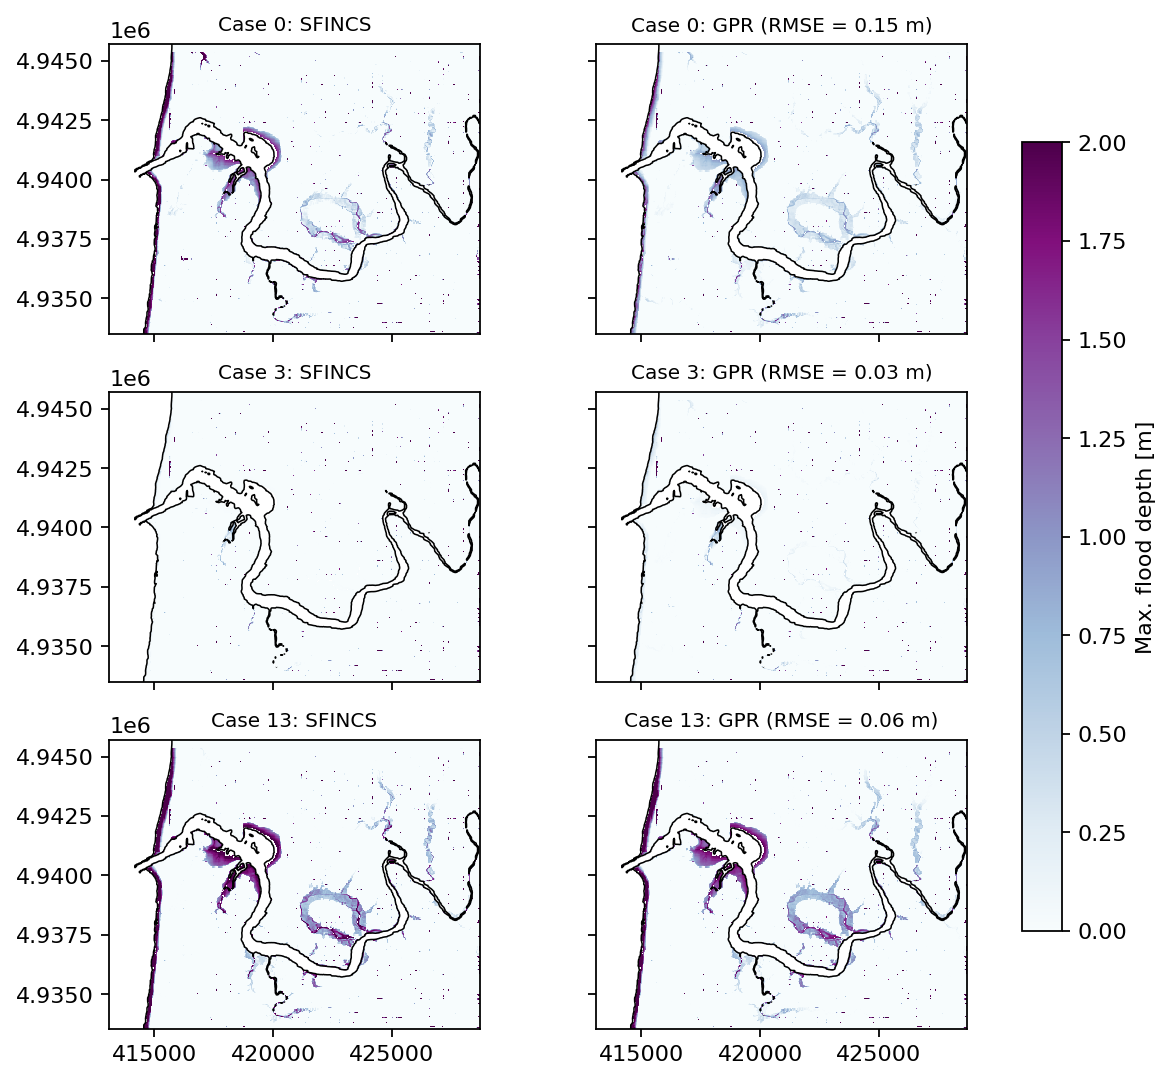

In [8]:
maps, titles = [], []

for i, case in enumerate(cases_to_validate):
    sfincs_map = sfincs_maps.isel(case_num=i)
    gp_map = gp_maps.isel(case_num=i)
    rmse = np.sqrt(((gp_map - sfincs_map) ** 2).mean()).item()

    maps += [sfincs_map, gp_map]
    titles += [f"Case {case}: SFINCS", f"Case {case}: GPR (RMSE = {rmse:.2f} m)"]

fig, axes = plot_output_cases(
    maps, dep_hr, ncols=2, cmap="BuPu", vmin=0, vmax=2, titles=titles, figsize=(9, 8)
)
plt.show()

> 💬 **Discussion:** Where are the largest errors? Why do you think the
> surrogate performs worse for some scenarios than for others? What would you
> do to improve it?

## 3. Reconstruction of new scenarios (LHS)

Now we can use the GPR to reconstruct the flood maps of scenarios that were
**never simulated** with SFINCS. As an example, we take a few random scenarios
from the 10,000 LHS samples generated in the previous notebook.

In [9]:
df_lhs = pd.read_pickle(op.join(export_dir, "lhs_dataset.pkl"))

df_lhs_sample = df_lhs.sample(6, random_state=42)
df_lhs_sample.round(2)

,Hs,Tp,Dir,SL,precipitation,precip_duration
6252,2.07,10.66,181.55,0.76,67.67,9.05
4684,1.44,11.04,284.38,1.16,70.32,9.43
1731,1.00,6.71,208.14,-0.02,24.15,1.56
4742,1.92,5.44,191.48,0.30,35.89,14.47
4521,1.50,10.56,201.48,0.35,12.71,9.44
6340,1.74,10.16,272.62,0.09,75.82,4.00


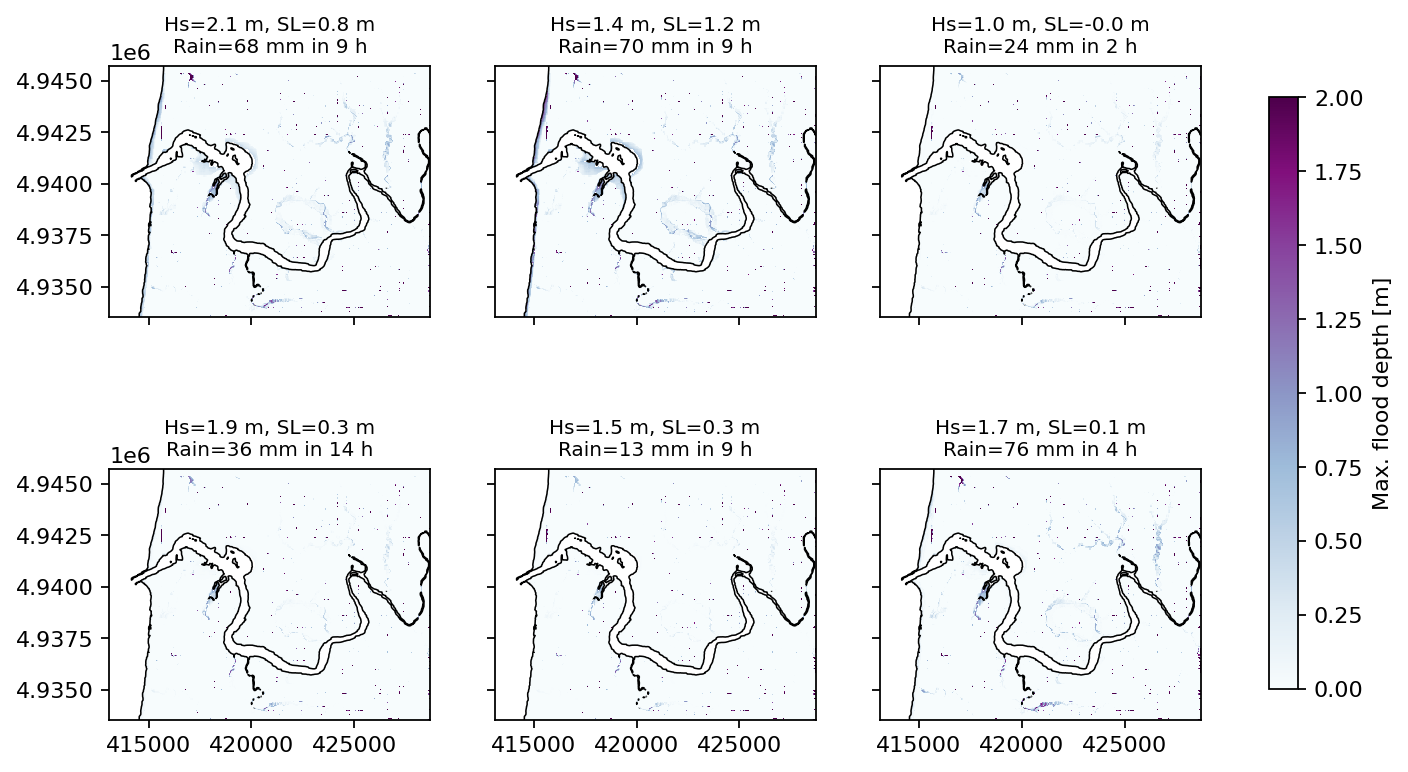

In [10]:
pcs_lhs = gp.predict(df_lhs_sample, return_std=True, verbose=0)
maps_lhs = pcs_to_flood_maps(pca, pcs_lhs)

titles = [
    f"Hs={row.Hs:.1f} m, SL={row.SL:.1f} m\n"
    f"Rain={row.precipitation:.0f} mm in {row.precip_duration:.0f} h"
    for row in df_lhs_sample.itertuples()
]

fig, axes = plot_output_cases(
    list(maps_lhs), dep_hr, cmap="BuPu", vmin=0, vmax=2, titles=titles, figsize=(11, 6)
)
plt.show()

> ⏱️ Reconstructing these maps takes a fraction of a second, while each SFINCS
> simulation took several seconds on this small grid (and can take hours for
> high-resolution models of large areas).

## 4. Sea level rise scenarios

A common application of a flooding surrogate is to evaluate how the impact of
a given storm changes under **sea level rise (SLR)**.

We define a **reference storm** and add different SLR values to its sea level:

| Variable | Reference storm |
|:---------|:---------------:|
| `Hs` | 2.8 m |
| `Tp` | 14 s |
| `Dir` | 270° (from the west) |
| `SL` | 1.0 m + SLR |
| `precipitation` | 40 mm |
| `precip_duration` | 12 h |

> ⚠️ The surrogate is only valid inside its training range. Since the scenarios
> were generated with `SL` up to 2.5 m, we can explore SLR values up to 1.5 m.

In [11]:
reference_storm = {
    "Hs": 2.8,
    "Tp": 14.0,
    "Dir": 270.0,
    "SL": 1.0,
    "precipitation": 40.0,
    "precip_duration": 12.0,
}

slr_values = [0.0, 0.5, 1.0, 1.5]

df_slr = pd.DataFrame([reference_storm] * len(slr_values), index=slr_values)
df_slr.index.name = "SLR"
df_slr["SL"] = reference_storm["SL"] + df_slr.index.values

df_slr

,Hs,Tp,Dir,SL,precipitation,precip_duration
SLR,,,,,,
0.0,2.8,14.0,270.0,1.0,40.0,12.0
0.5,2.8,14.0,270.0,1.5,40.0,12.0
1.0,2.8,14.0,270.0,2.0,40.0,12.0
1.5,2.8,14.0,270.0,2.5,40.0,12.0


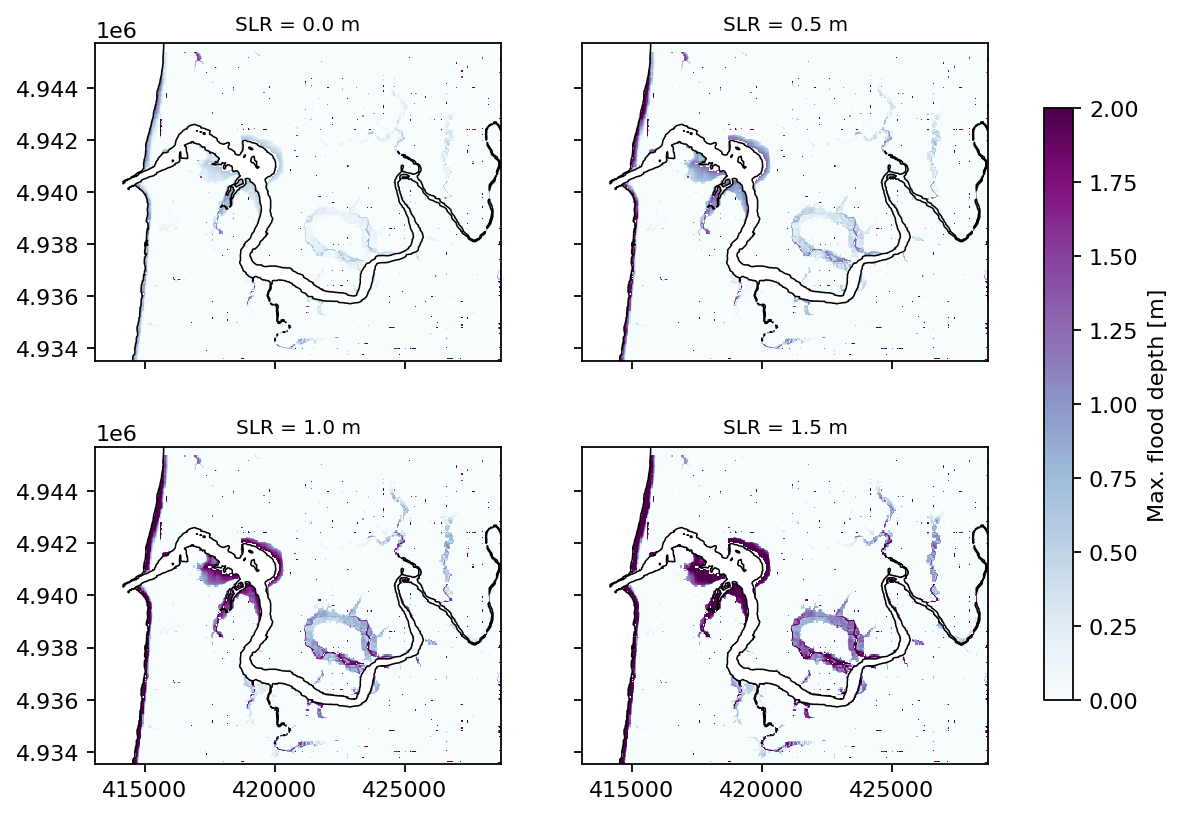

In [12]:
pcs_slr = gp.predict(df_slr.reset_index(drop=True), return_std=True, verbose=0)
maps_slr = pcs_to_flood_maps(pca, pcs_slr)

fig, axes = plot_output_cases(
    list(maps_slr),
    dep_hr,
    ncols=2,
    cmap="BuPu",
    vmin=0,
    vmax=2,
    titles=[f"SLR = {slr} m" for slr in slr_values],
    figsize=(9, 6),
)
plt.show()

### 4.1. Uncertainty of the reconstruction

For each scenario, the GP gives the mean and the uncertainty of every PC. To
translate this into uncertainty of the flood maps, we draw **random samples of
the PCs** from the GP predictive distribution and reconstruct a flood map for
each of them.

With these samples we can compute, for instance, the **standard deviation of
the flood depth** and a **confidence interval of the flooded area**.

In [13]:
n_samples = 200
pc_names = list(df_train_pcs.columns)

area_samples, std_maps = [], []

for i in range(len(slr_values)):
    pcs_samples = sample_pcs(pcs_slr.iloc[i], pc_names, n_samples=n_samples, seed=i)
    maps_samples = pcs_to_flood_maps(pca, pcs_samples)

    area_samples.append(flooded_area_km2(maps_samples).values)
    std_maps.append(maps_samples.std(dim="case_num"))

area_samples = np.array(area_samples)
area_mean = flooded_area_km2(maps_slr).values

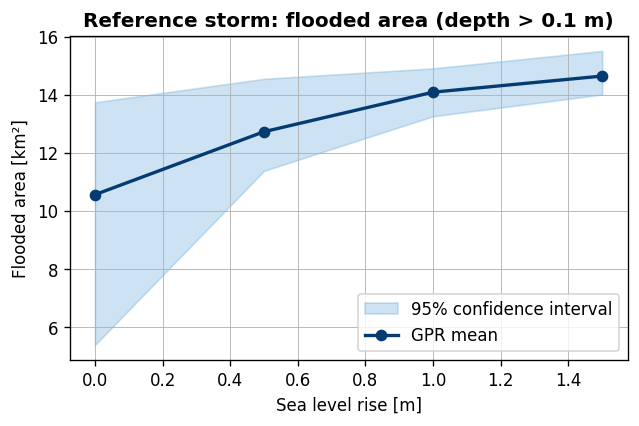

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5), dpi=120)

ax.fill_between(
    slr_values,
    np.percentile(area_samples, 2.5, axis=1),
    np.percentile(area_samples, 97.5, axis=1),
    color="#5AA1D4",
    alpha=0.3,
    label="95% confidence interval",
)
ax.plot(slr_values, area_mean, "o-", color="#053B71", lw=2, label="GPR mean")

ax.set_xlabel("Sea level rise [m]")
ax.set_ylabel("Flooded area [km²]")
ax.set_title("Reference storm: flooded area (depth > 0.1 m)", fontweight="bold")
ax.grid(lw=0.5)
ax.legend()
plt.show()

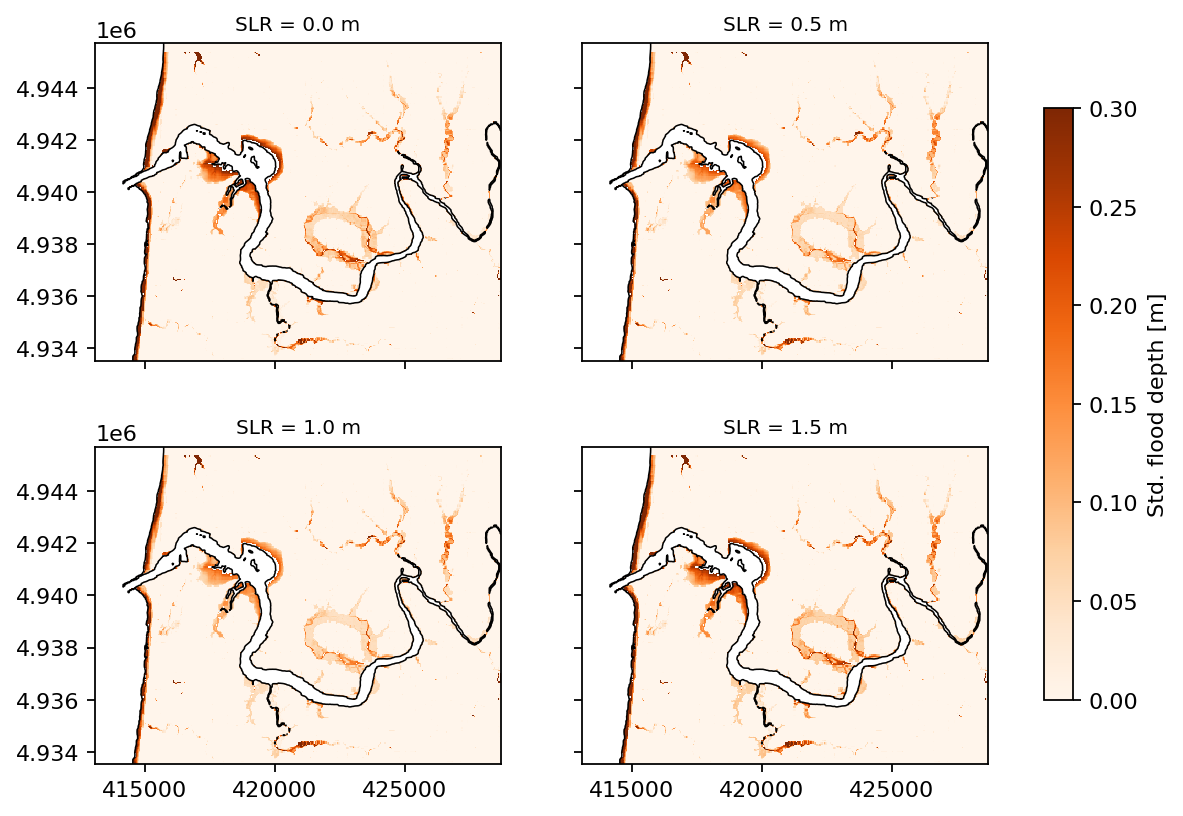

In [15]:
fig, axes = plot_output_cases(
    std_maps,
    dep_hr,
    ncols=2,
    cmap="Oranges",
    vmin=0,
    vmax=0.3,
    titles=[f"SLR = {slr} m" for slr in slr_values],
    label="Std. flood depth [m]",
    figsize=(9, 6),
)
plt.show()

> 💬 **Discussion:** How does the flooded area grow with SLR? Is the increase
> linear? Where is the reconstruction most uncertain, and why?

## Summary

In this notebook, we:

- Trained a **Gaussian Process Regression** surrogate model that relates the
  forcing conditions (waves, sea level and rain) to the PCs of the SFINCS flood
  maps.
- Validated it with a **leave-one-out** test against SFINCS simulations it had
  never seen.
- Reconstructed the flood maps of **new LHS scenarios** in a fraction of a second.
- Evaluated the impact of **sea level rise** on a reference storm, including the
  **uncertainty** of the reconstruction.

This completes the HyFlood workflow:

**BinWaves → HySwash → SFINCS → PCA → GPR**

With more training simulations, the same framework can be used to reconstruct
decades of historical flooding from hindcast data, or thousands of synthetic
events to estimate flood hazard under present and future climate.